# `=== Atelier Scikit-learn ===`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Importation du dataset
df = pd.read_csv("../data/mesures_capteurs.csv")

# Exploration du dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


## `Partie 1 – Gestion des doublons`

### `1.1: Vérification de l’existence de doublons dans df`

In [10]:
print(f" Duplications: {df.duplicated().sum()}")

 Duplications: 5


### `1.2: Suppression des doublons`

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### `1.3: gestion des Valeurs manquantes`

In [14]:
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

In [15]:
# Statistiques descriptives
df.describe()

,temperature,humidite,pression,consommation
count,594.000000,595.000000,595.000000,595.000000
mean,24.896212,64.863395,1012.241059,208.693294
std,4.068454,10.760478,10.623413,72.320179
min,-18.500000,28.520000,850.000000,18.120000
25%,22.597500,58.090000,1006.890000,160.500000
50%,24.870000,65.370000,1012.960000,206.130000
75%,27.295000,71.590000,1017.835000,254.265000
max,58.700000,145.000000,1038.430000,875.000000


In [16]:
# Gestion des veleurs manquantes pour la variable numeriques
# colonne température
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
# Colonne consommation
df['consommation'] = df['consommation'].fillna(df['consommation'].median())
# Colonne humidite
df['humidite'] = df['humidite'].fillna(df['humidite'].median())
# Colonne pression
df['pression'] = df['pression'].fillna(df['pression'].median())
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     600 non-null    str    
 1   date_heure    600 non-null    str    
 2   id_capteur    600 non-null    str    
 3   batiment      600 non-null    str    
 4   temperature   600 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          596 non-null    str    
dtypes: float64(4), str(5)
memory usage: 46.9 KB


In [17]:
# Gestion des veleurs manquantes pour la variable numeriques
df["etat"].mode()

0    OK
Name: etat, dtype: str

In [18]:
df["etat"] = df["etat"].fillna("OK")
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     0
humidite        0
pression        0
consommation    0
etat            0
dtype: int64

## `Partie 2 – Sélection de y (cible) et X (caractéristiques)`

### `2.1: On définit "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives`

`Selection des features`

In [25]:
X = df[['temperature', 'humidite', 'pression', 'consommation']]

`Selection des labels`

In [26]:
y = df[['etat']]


### `2.2: Affichage des cinq premières lignes de X et de y`

In [27]:
X.head()

,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


In [28]:
y.head()

,etat
0,OK
1,OK
2,OK
3,OK
4,OK


### `2.3: Quel est le type du problème de machine learning ?`

Le type de problème en question est un problème de classification, l'objectif est de classer les enreigistrements dans les classe: `OK`, `ALERTE` et `ERREUR` en fontion des valeurs de la temperature, de l'humidité, de la pression et de la consommation

## `Partie 3 – Découpage Train/Test`

#### `3.1:` Division de `X `en deux ensembles distincts : un pour l'entraînement `(train)` et un pour le test `(test)`. Avec les conditions suivantes : `20%` des données serviront au test ; garantir la `reproductibilité` du découpage ; conserver les mêmes `proportions de classes` dans l'ensemble de `train` et de `test` que dans les données d'origine`

In [33]:
from sklearn.model_selection import train_test_split

# Division en train et test des features et labels
X_train, X_test, y_train, y_test = train_test_split(
     X,                  # Features
     y,                  # Target
     test_size=0.2,      # 20% des données pour le test
     random_state=42,    # Garantir la reproductibilité du découpage
     stratify=y          # conserver les meme proportions de classe dans train et test
)

## `Partie 4 – Gestion des valeurs manquantes`

### `4.1: Vérification de l’existence de valeurs manquantes`

In [29]:
X.isnull().sum()

temperature     0
humidite        0
pression        0
consommation    0
dtype: int64

### `4.2: Sélection de SimpleImputer avec la médiane`

In [34]:
from sklearn.impute import SimpleImputer

# Instanciation de l'imputeur
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

### `4.3: Qu’est ce qui justifie le choix de la médiane ?`

Le dataset en question contient des outliers (valeurs abérantes) et cela influx sur le calcul de la moyenne et de la variance, et pas sur la mediane; ce qui justifie le choix de la médiane

### `4.4: Les paramètres (médianes) de l’imputeur sur X_train`

In [54]:
medianes = imputer.statistics_

for col, med in zip(X_train.columns, medianes):
     print(f"{col}  --- : {med:.4f}")

temperature  --- : 24.8700
humidite  --- : 65.3350
pression  --- : 1012.6700
consommation  --- : 206.1300


### `4.5: On déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test`

In [37]:
X_train_imputed

array([[  58.7 ,   81.51, 1026.79,  271.92],
       [  26.2 ,   76.27, 1016.74,  191.33],
       [  27.27,   75.68, 1013.78,  335.2 ],
       ...,
       [  21.64,   52.74, 1002.78,  157.77],
       [  26.27,   68.79, 1003.12,  244.9 ],
       [  32.72,   53.28, 1010.05,  195.37]], shape=(480, 4))

In [38]:
X_test_imputed

array([[  19.27,   58.39, 1003.74,  136.56],
       [  25.96,   62.79, 1012.17,  228.74],
       [  24.87,   69.97, 1014.14,  181.07],
       [  33.29,   50.43, 1009.87,  356.76],
       [  30.38,   65.98, 1005.48,  256.18],
       [  27.85,   58.01, 1012.29,  208.09],
       [  26.04,   67.17, 1011.38,  253.99],
       [  28.66,   35.83, 1022.52,  142.86],
       [  25.02,   79.27, 1027.7 ,  214.88],
       [  20.71,   72.01, 1002.15,  144.24],
       [  24.86,   68.77, 1003.98,  289.79],
       [  25.91,   49.2 , 1016.57,  201.37],
       [  29.5 ,   81.47, 1015.48,  256.53],
       [  27.33,   89.45, 1001.98,  346.24],
       [  22.96,   42.4 , 1011.47,  142.67],
       [  23.64,   48.79,  994.25,  222.42],
       [  20.72,   75.27,  997.63,  230.8 ],
       [  22.79,   68.34, 1013.41,  115.55],
       [  30.92,   67.19, 1009.71,  329.78],
       [  26.06,   77.13, 1021.87,  108.36],
       [  29.97,   68.65, 1007.19,  267.37],
       [  24.3 ,   58.75, 1023.6 ,  244.86],
       [  

## `Partie 5 – Mise à l'échelle`

### `5.1: Sélection de StandardScaler pour mettre à l’échelle les transformés de l’imputation`

In [40]:
from sklearn.preprocessing import StandardScaler

# Instanciation de l'objet scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
x_test_scaled = scaler.transform(X_test_imputed)

### `5.2: Qu’est ce qui justifie la standardisation ?`

On applique la `standardisation` pour que les valeurs des differentes variable partage une echèlle comparable, et comme notre dataset contient des outliers il est indispensable de mettre à l'échelle les valeur d'oú l'importance de la standardisation,. De plus certains algo sont sensibles à l'echelle des variables.

### `5.3: On donne les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed`

`Moyennes`

In [60]:
means = scaler.mean_
print(f"Moyennes de chaque features:")
for col, med in zip(X_train.columns, means):
     print(f"{col}  --- : {med:.4f}")

Moyennes de chaque features:
temperature  --- : 24.9269
humidite  --- : 64.6353
pression  --- : 1011.9900
consommation  --- : 208.4475


`Ecart-types`

In [59]:
ecart_types = scaler.mean_
print(f"Ecart-types de chaque features:")
for col, med in zip(X_train.columns, ecart_types):
     print(f"{col}  --- : {med:.4f}")

Ecart-types de chaque features:
temperature  --- : 24.9269
humidite  --- : 64.6353
pression  --- : 1011.9900
consommation  --- : 208.4475


### `5.4: On déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed`

In [64]:
print(X_train_scaled)

[[ 8.16891196  1.67353001  1.35520087  0.85676261]
 [ 0.30793852  1.15385897  0.43494622 -0.23105564]
 [ 0.56674595  1.09534639  0.16390605  1.71092738]
 ...
 [-0.79501653 -1.17970203 -0.84333784 -0.68405453]
 [ 0.32486984  0.41203847 -0.81220485  0.49204181]
 [ 1.88497073 -1.12614814 -0.17764119 -0.176523  ]]


In [63]:
print(x_test_scaled)

[[-1.36826290e+00 -6.19369700e-01 -7.55432917e-01 -9.70350911e-01]
 [ 2.49888252e-01 -1.83004703e-01  1.64821727e-02  2.73911236e-01]
 [-1.37567035e-02  5.29063633e-01  1.96870396e-01 -3.69546960e-01]
 [ 2.02284011e+00 -1.40879365e+00 -1.94123368e-01  2.00194812e+00]
 [ 1.31898064e+00  1.33359920e-01 -5.96105247e-01  6.44301270e-01]
 [ 7.07034092e-01 -6.57055768e-01  2.74702879e-02 -4.82616144e-03]
 [ 2.69238340e-01  2.51376817e-01 -5.58562520e-02  6.14740258e-01]
 [ 9.02953738e-01 -2.85673205e+00  9.64207105e-01 -8.85312382e-01]
 [ 2.25247124e-02  1.45138056e+00  1.43852741e+00  8.68264745e-02]
 [-1.01996130e+00  7.31378314e-01 -9.01025442e-01 -8.66684895e-01]
 [-1.61754646e-02  4.10054998e-01 -7.33456686e-01  1.09797507e+00]
 [ 2.37794447e-01 -1.53077750e+00  4.19379728e-01 -9.55339248e-02]
 [ 1.10612967e+00  1.66956306e+00  3.19571016e-01  6.49025633e-01]
 [ 5.81258517e-01  2.46097048e+00 -9.16591939e-01  1.85994728e+00]
 [-4.75740066e-01 -2.20515977e+00 -4.76151657e-02 -8.87877036e

## `Partie 6: Ecodage de la Target`

In [79]:

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['OK', 'ALERTE', 'ERREUR']])

y_train_encoded = encoder.fit_transform(y_train).ravel()
y_test_encoded = encoder.transform(y_test).ravel()

""" 
Encodage avec pandas
mapping_cible = {'OK': 0, 'ALERTE': 1, 'ERREUR': 2}

# Appliquer sur votre variable cible
y_train_encoded = y_train['etat'].map(mapping_cible)
y_test_encoded = y_test['etat'].map(mapping_cible) """

y_train_encoded


array([2., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 2., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 2., 0., 0.

## `Partie 7 – Entrainement et prédiction d’un modèle`

### `7.1: Sélection du modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte`

In [83]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

### `7.2: Entrainement du modèle`

In [84]:
import time

temps_debut = time.time()
print(f"Début de l'entraînement : {time.strftime('%H:%M:%S', time.localtime(temps_debut))}")

knn.fit(X_train_scaled, y_train_encoded)

temps_fin = time.time()
print(f"Fin de l'entraînement   : {time.strftime('%H:%M:%S', time.localtime(temps_fin))}")

# 5. Calculer et afficher la durée totale
print(f"Durée totale de l'entraînement : { temps_fin - temps_debut:.4f} secondes")


Début de l'entraînement : 15:08:37
Fin de l'entraînement   : 15:08:37
Durée totale de l'entraînement : 0.0047 secondes


### `7.3: On détermine y_pred, la prédiction du modèle avec l’ensemble de test`

In [100]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_encoded = knn.predict(x_test_scaled)

### `7.4: Affichage de quelques prédictions`

In [101]:
y_pred_texte = encoder.inverse_transform(y_pred_encoded.reshape(-1, 1)).ravel()
y_test_texte = encoder.inverse_transform(y_test_encoded.reshape(-1, 1)).ravel()

In [102]:
print(y_pred_texte[:5])

['OK' 'OK' 'OK' 'ALERTE' 'OK']


### `7.5: Comparaison des prédictions avec les vraies valeurs`

In [104]:
exactitude = accuracy_score(y_test_texte, y_pred_texte)
print(f"Taux de prédictions correctes : {exactitude * 100:.2f}%\n")

# 3. Boucle pour afficher les 10 premières valeurs
print(f"{'Index':<6} | {'Valeur Réelle':<15} | {'Valeur Prédite':<15} | Statut")
print("-" * 55)

for i in range(10):
    reelle = y_test_texte[i]
    predite = y_pred_texte[i]
    statut = "✅ Correct" if reelle == predite else "❌ Erreur"
    
    print(f"{i:<6} | {reelle:<15} | {predite:<15} | {statut}")

Taux de prédictions correctes : 96.67%

Index  | Valeur Réelle   | Valeur Prédite  | Statut
-------------------------------------------------------
0      | OK              | OK              | ✅ Correct
1      | OK              | OK              | ✅ Correct
2      | OK              | OK              | ✅ Correct
3      | ALERTE          | ALERTE          | ✅ Correct
4      | OK              | OK              | ✅ Correct
5      | OK              | OK              | ✅ Correct
6      | OK              | OK              | ✅ Correct
7      | OK              | OK              | ✅ Correct
8      | OK              | OK              | ✅ Correct
9      | OK              | OK              | ✅ Correct


## `Partie 8: – Evaluation du modèle`

### `8.1: Evaluation du modèle avec Accuracy puis affichage le résultat`

In [120]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

exactitude = accuracy_score(y_test_texte, y_pred_texte)
print(f"Accuracy : {exactitude * 100:.2f}%\n")

Accuracy : 96.67%



### `8.2: Pourquoi Accuracy ne suffit pas toujours pour évaluer ?`

L'`accuracy` seule peut être trompeuse sur des jeux de données déséquilibrés : un `modèle`
qui prédit toujours la `classe majoritaire` peut obtenir une `accuracy élevée` sans être réellement
performant. Dans ce cas, la `précision`, le rappel et le `F1-score` (en particulier sur la `classe minoritaire`) donnent une image plus dèle de la qualité du modèle.

### `8.3: On détermine, puis afficher et commenter la matrice de confusion`

In [ ]:
print("\n--- MATRICE DE CONFUSION ---")
indices_colonnes = ['OK', 'ALERTE', 'ERREUR']
matrice = confusion_matrix(y_test_texte, y_pred_texte, labels=indices_colonnes)

df_matrice = pd.DataFrame(
               matrice, 
               index=[f"Réel {x}" for x in indices_colonnes], 
               columns=[f"Prédit {x}" for x in indices_colonnes]
               )
print(df_matrice)


--- MATRICE DE CONFUSION ---
             Prédit OK  Prédit ALERTE  Prédit ERREUR
Réel OK            113              0              0
Réel ALERTE          3              3              0
Réel ERREUR          0              1              0


`1. Les succès du modèle (La diagonale)`

Pour savoir ce que le modèle a bien prédit, il faut regarder la ligne diagonale qui descend de gauche à droite
 `:113 cas OK` ont été parfaitement prédits comme OK. Le modèle ne se trompe jamais sur ce qui est normal.

 `3 cas ALERTE` ont été parfaitement prédits comme `ALERTE`.
 
 `0 cas ERREUR` ont été prédits comme `ERREUR`. Le modèle n'a jamais réussi à détecter une seule vraie erreur.

 `2. Les erreurs du modèle (En dehors de la diagonale)`
 
 Ce sont les cas où le modèle s'est "confondu" :
 
 `3 fausses sécurités (OK)` : Il y avait `6 vraies ALERTE` au total. 
 
 Le modèle en a trouvé 3, mais pour les `3 autres`, il a prédit que tout était OK. 
 
 C'est un comportement risqué, car le système a ignoré des anomalies mineures.
 
 `1 alerte sous-estimée` : Il y avait 1 seule vraie ERREUR dans vos données. Le modèle l'a manquée et l'a classée comme une simple ALERTE. Il n'a donc pas vu la gravité de la panne.

### `8.4: Visualisation de la matrice avec Seaborn`

Text(50.38563368055554, 0.5, 'Classes Réelles')

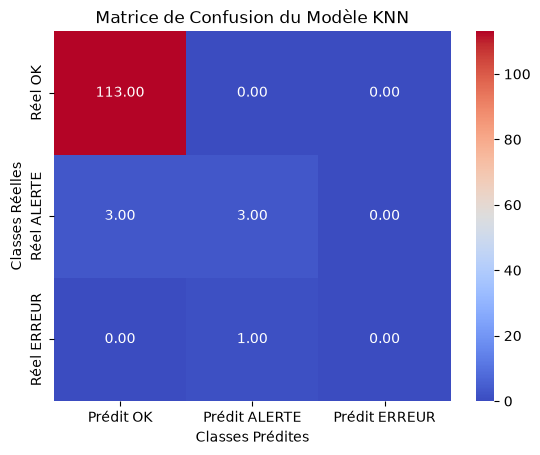

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_matrice, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Matrice de Confusion du Modèle KNN')
plt.xlabel('Classes Prédites')
plt.ylabel('Classes Réelles')

### `8.5: Affichage et commentaire du rapport de classificaton`

/Users/alassanembengue/Desktop/IA_ODC/PYTHON/python_ml_ia(2)/python_for_ml_ai_2/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alassanembengue/Desktop/IA_ODC/PYTHON/python_ml_ia(2)/python_for_ml_ai_2/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alassanembengue/Desktop/IA_ODC/PYTHON/python_ml_ia(2)/python_for_ml_ai_2/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being

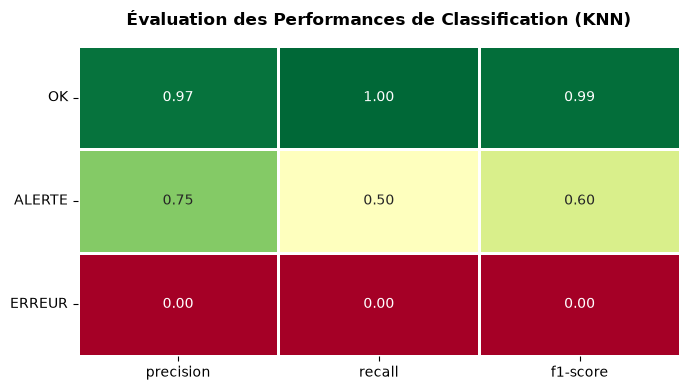

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Récupérer les données propres
report_dict = classification_report(y_test_texte, y_pred_texte, output_dict=True)
df_heatmap = pd.DataFrame(report_dict).T.loc[['OK', 'ALERTE', 'ERREUR'], ['precision', 'recall', 'f1-score']]

# 2. Dessin du graphique
plt.figure(figsize=(7, 4))
sns.heatmap(
    df_heatmap, 
    annot=True, 
    fmt=".2f", 
    cmap="RdYlGn",  # Vert pour les bons scores, Rouge pour les mauvais
    vmin=0, 
    vmax=1,
    linewidths=1,   # Sépare légèrement les cases
    cbar=False      # Masque la barre latérale pour un rendu plus épuré
)

plt.title("Évaluation des Performances de Classification (KNN)", fontsize=12, pad=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


Ligne `OK` (`Tout au vert`) : Le modèle est parfait. Il trouve tous les cas normaux `(1.00)` et ne se trompe jamais quand il les annonce `(0.97)`.

Ligne `ALERTE` `(En jaune ) `: Le modèle est moyen. Il manque la moitié des vraies alertes (0.50), mais quand il en trouve une, il est plutôt fiable (0.75).

Ligne `ERREUR` (`Tout au rouge` ) : Le modèle échoue totalement `(0.00)`. Il est incapable de détecter la moindre erreur critique.

`Conclusion générale` : Le graphique montre visuellement que votre modèle est inutile pour la sécurité, car il ne voit pas les pannes (rouge) et rate une alerte sur deux (jaune).

### `8.6: Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même question avec recall; même question avec F1 score; même question avec accuracy`

`1. L'Accuracy (Taux de réussite global)`

* Quand l'utiliser : Quand vos classes sont équilibrées (il y a autant de cas positifs que de cas négatifs dans vos données).
* En mots simples : Elle répond à la question : "Globalement, combien de fois le modèle a-t-il donné la bonne réponse ?"
* Le piège : Elle est inutile si une classe est ultra-majoritaire (comme votre classe `OK` à 97 %).

`2. Le Recall / Rappel (Sensibilité)`

* Quand l'utiliser : Quand manquer un cas positif est grave ou dangereux (ex: diagnostics médicaux, fraudes fiscales, pannes serveurs ou vos classes `ERREUR`).
* En mots simples : Il répond à la question : "Sur toutes les vraies erreurs qui existaient, quel pourcentage le modèle a-t-il réussi à attraper ?"
* Le but : Ne rien laisser passer, quitte à faire de fausses alertes.

`3. La Precision`

* Quand l'utiliser : Quand faire une fausse alerte coûte cher ou est très pénalisant (ex: filtres anti-spam, systèmes de blocage automatique de comptes).
* En mots simples : Elle répond à la question : "Quand le modèle lève une alerte, à quel point est-il sûr de lui ?"
* Le but : Être extrêmement fiable à chaque prédiction, quitte à rater certains cas.

`4. Le F1-Score`

* Quand l'utiliser : Quand vos classes sont déséquilibrées (comme votre projet) et que vous cherchez un compromis parfait entre la Précision et le Rappel.
* En mots simples : C'est la moyenne équilibrée des deux. Il répond à la question : "Est-ce que le modèle est globalement performant sans trop sacrifier la détection (Recall) ni la fiabilité (Precision) ?"
* Le but : Avoir un score unique et honnête pour juger un modèle sur des données difficiles.

 

## `Partie 9 – Sauvegarde du modèle`

### `9.1: Sauvegarde du modèle avec Joblib pour avoir models/modele_capteurs.joblib`

`Joblib`

In [144]:
import joblib
import pickle

joblib.dump(knn, "../models/knn_v1.joblib")

['../models/knn_v1.joblib']

`Pickle`

In [145]:
with open("../models/knn_v1.pkl", "wb") as f:
    pickle.dump(knn, f)

## `Partie 10 – Chargement du modèle`

### `10.1: Chargement du modèle`

In [147]:
knn_model = joblib.load("../models/knn_v1.joblib")
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[float64](3,)","[0.,1.,2.]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### `10.2:  Prédiction avec une nouvelle mesure`

In [ ]:
nouvelles_donnees = pd.DataFrame(
    {
        "temperature": [22.5, 28.1],
        "humidite": [55.2, 61.4],
        "pression": [1008.5, 1011.2],
        "consommation": [140.5, 230.1],  # Vos valeurs réelles de test
    }
)

nouvelles_donnees["prediction"] = predictions
dictionnaire_classes = {
    0.0: "OK",
    1.0: "ALERTE",   
    2.0: "ERREUR"
}

# Remplacement des chiffres par le texte explicite
nouvelles_donnees["prediction_texte"] = nouvelles_donnees["prediction"].map(
    dictionnaire_classes
)
# Affichage du résultat final
nouvelles_donnees

,temperature,humidite,pression,consommation,prediction,prediction_texte
0,22.5,55.2,1008.5,140.5,0.0,OK
1,28.1,61.4,1011.2,230.1,0.0,OK
